In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import sys

sys.path.append("../../scripts")
import readwrite

cfg = readwrite.config()

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/__init__.py:44: F

## Params

In [2]:
donor_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'donor_palette.csv',index_col=0)
cell_type_palette = pd.read_csv(cfg['xenium_metadata_dir'] + 'cell_type_palette.csv',index_col=0)


xenium_dir = Path(cfg["xenium_processed_dir"])
xenium_count_correction_dir = Path(cfg["xenium_count_correction_dir"])
xenium_std_seurat_analysis_dir = Path(cfg["xenium_std_seurat_analysis_dir"])
xenium_cell_type_annotation_dir = Path(cfg["xenium_cell_type_annotation_dir"])
results_dir = Path(cfg["results_dir"])

# input params
cellcharter_dir = "cellcharter_cohort"
correction_method = "raw"
segmentation = "proseg_expected"
condition = "all"
panel = "all"
normalisation = "lognorm"
reference = "GEO_GSE178341"
method = "rctd_class_aware"
level = "Level1"
xenium_levels = ["segmentation", "condition", "panel", "donor", "sample"]
name_malignant = "Epi"

# qc params
min_n_counts = 20

# fixed params
BATCH_KEY = "dataset_id"
SPATIAL_KEY = "spatial"
N_CLUSTERS_RANGE = (5, 19)
MAX_RUNS = 10
CONVERGENCE_TOL = 0.001

# output paths
wildcards = f"{cellcharter_dir}/{correction_method}/{segmentation}"
if cellcharter_dir != "cellcharter_cohort":
    wildcards += f"/{condition}/{panel}"

OUTPUT_LABELS = results_dir / f"xenium/{wildcards}/labels.parquet"
OUTPUT_SCVI_MODEL = results_dir / f"xenium/{wildcards}/scvi_model"
OUTPUT_CELLCHARTER_MODELS = results_dir / f"xenium/{wildcards}/cellcharter_models"
OUTPUT_PLOT = results_dir / f"xenium/{wildcards}/autok_stability.png"
OUTPUT_X_SCVI = results_dir / f"xenium/{wildcards}/X_scvi.parquet"
OUTPUT_X_CELLCHARTER = results_dir / f"xenium/{wildcards}/X_cellcharter.parquet"


segmentations_filter = [segmentation]
conditions_filter = [condition] if condition != "all" else None
panels_filter = [panel] if panel != "all" else None

# Read results

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'cell_polygons', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_o

Exclude 169V peritoneal sample
Could not find annotation file for ('proseg_expected', 'CRC_PDO_DEV', 'hImmune_v1_mm', '10_OY6Hmiddlebig', 'output-XETG00059__0033028__10_OY6Hmiddlebig__20250811__161841'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC_PDO_DEV/hImmune_v1_mm/10_OY6Hmiddlebig/output-XETG00059__0033028__10_OY6Hmiddlebig__20250811__161841/lognorm/reference_based/GEO_GSE178341/rctd_class_aware/Level1/single_cell/labels.parquet
Could not find annotation file for ('proseg_expected', 'CRC_PDO_DEV', 'hImmune_v1_mm', '12_OY6Hbighuge', 'output-XETG00059__0033028__12_OY6Hbighuge__20250811__161841'): /work/PRTNR/CHUV/DIR/rgottar1/spatial/data/norkin_organoid/data/xenium/processed/cell_type_annotation/proseg_expected/CRC_PDO_DEV/hImmune_v1_mm/12_OY6Hbighuge/output-XETG00059__0033028__12_OY6Hbighuge__20250811__161841/lognorm/reference_based/GEO_GSE178341/rctd_class_aware/Level1/single_cell/labels.parquet
Could n

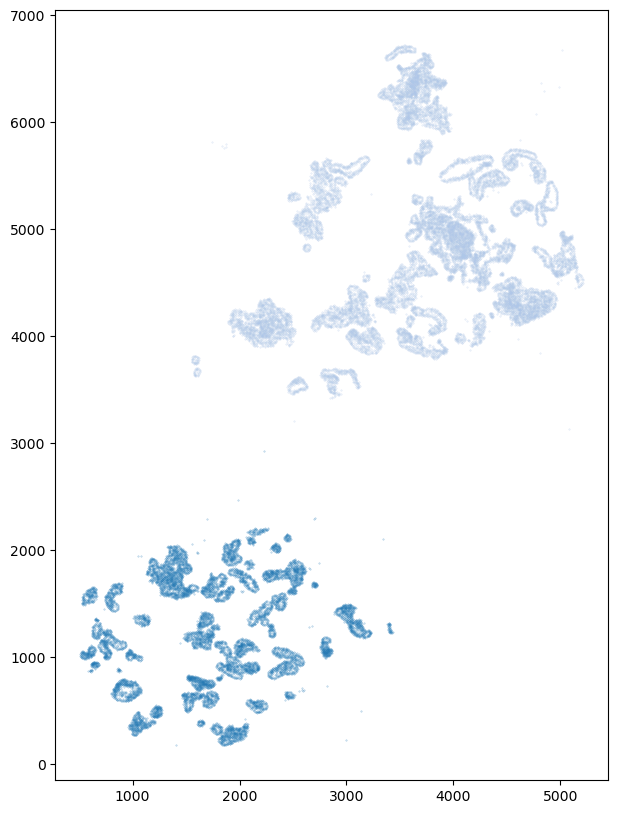

Removing 6 cells from excluded samples of 9_11_OY6H_middle_and_big
8samples


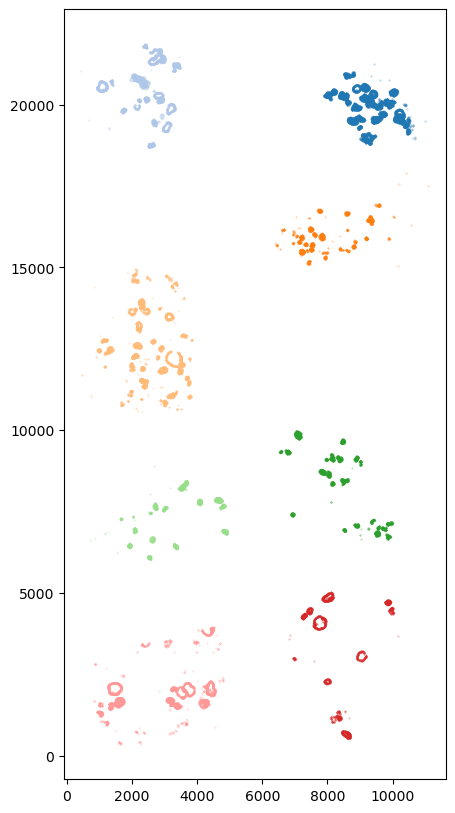

Removing 48 cells from excluded samples of 8samples
18samples


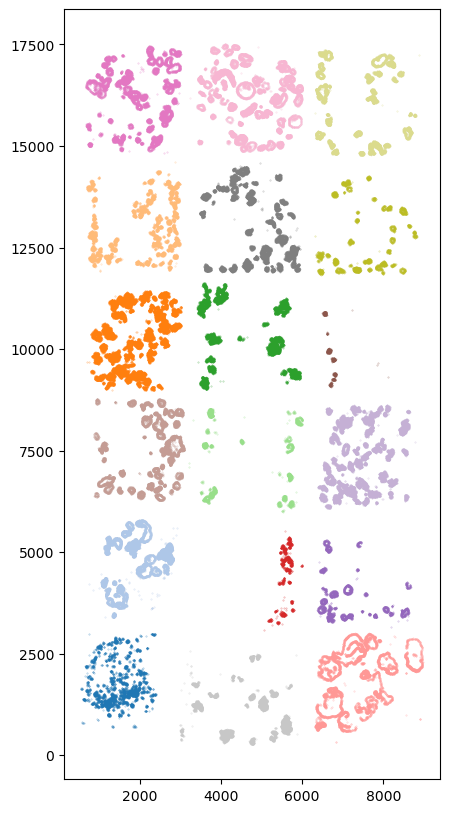

Removing 59063 cells from excluded samples of 18samples


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Keeping only run2 samples for CRC_PDO 1GAA and 077I


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Changing condition from CRC_PDO to CRC_PDO_CAF for 18042 cells


...

/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 17796 cells creating outlier leiden cluster after integration
Filtering out 110596 cells with less than 20 counts


/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/work/PRTNR/CHUV/DIR/rgottar1/spatial/env/norkin_organoid/.pixi/envs/cellcharter/lib/python3.12/site-packages/anndata/_core/anndata.py:1774: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Filtering out 28128 cells from bad spatial regions
cohort info:


,donor,sample
CRC_PDO_DEV,6,6
CRC,14,14
CRC_PDO_CAF,10,10
CRC_PDO,38,38


In [ ]:
# read samples
xenium_paths, xenium_annot_paths = readwrite.discover_xenium_paths(
    analysis_dir=xenium_std_seurat_analysis_dir,
    data_dir=xenium_dir,
    annotation_dir=xenium_cell_type_annotation_dir,
    correction_dir=xenium_count_correction_dir,
    normalisation=normalisation,
    reference=reference,
    method=method,
    level=level,
    correction_methods_filter=[correction_method],
    segmentations_filter=[segmentation],
    conditions_filter=conditions_filter,
    panels_filter=panels_filter,
)


# set transcripts=True to load individual transcripts positions)
if correction_method != "raw":
    ads = readwrite.read_count_correction_samples(xenium_paths, [correction_method])
else:
    ads = {}
    ads["raw"] = readwrite.read_xenium_samples(xenium_paths["raw"], anndata=True, pool_mode="thread", max_workers=6)

# remove 169V sample
print("Exclude 169V peritoneal sample")
ads['raw'] = { k:v for k,v in ads['raw'].items() if k[-2] != '169V' }

# add cell type annotation from raw to all correction methods
readwrite.read_annotations(ads, [correction_method], xenium_annot_paths, level, max_workers=8)

# split 18samples and 8samples, keep only samples needed for analysis according to csvs
samples2split = ['18samples','8samples','9_11_OY6H_middle_and_big']
samples2split_dict = {k[-2]: k for k in ads['raw'].keys() if k[-2] in samples2split}
coords_csv_dict = {k: cfg["xenium_metadata_dir"] + f"Regions_coordinates_{k}.csv" for k in samples2split}
readwrite.split_samples_by_coords(ads, samples2split_dict, coords_csv_dict, plot = True)

# concat samples
genes = [v.var_names for k, v in ads[correction_method].items()]
common_genes = list(set(genes[0]).intersection(*genes[1:]))

adata = sc.concat({k: v for k, v in ads[correction_method].items()}, label="dataset_id", join="outer")[
    :, common_genes
].copy()


# create metadata, full cell identifiers
adata.obs[xenium_levels] = pd.DataFrame(adata.obs["dataset_id"].tolist(), index=adata.obs.index, columns=xenium_levels)
adata.obs["correction_method"] = correction_method
adata.obs['cell_id'] = 'proseg-' + adata.obs['cell_id'].astype(str)
adata.obs['full_id'] = adata.obs[['segmentation', 'condition', 'panel', 'donor', 'sample','cell_id']].agg('_'.join, axis=1)
adata.obs["donor_corrected"] = adata.obs["donor_corrected"].fillna(adata.obs["donor"])
adata.obs["sample_corrected"] = adata.obs["sample_corrected"].fillna(adata.obs["sample"])

# all other conditions are Epi cells
adata.obs.loc[adata.obs['condition'] != 'CRC', level] = 'Epi'

# keep only run2 samples for 1GAA and 077I
print('Keeping only run2 samples for CRC_PDO 1GAA and 077I')
run2samples2keep = ['output-XETG00059__0003381__1GAA__20250505__170803','output-XETG00059__0003381__077I__20250505__170803']
adata = adata[
    ~(
        (adata.obs['condition'] == 'CRC_PDO') 
        & (adata.obs['donor'].isin(['077I','1GAA'])) 
        & (~(adata.obs['sample'].isin(run2samples2keep)))
    )
].copy()


# correct condition label for split samples
ix_correct_condition = (
    (adata.obs['condition'] == 'CRC_PDO') 
    & (adata.obs['donor_corrected'].isin(['1HVQ_big','1HVQ_big_CAFs'])))
print('Changing condition from CRC_PDO to CRC_PDO_CAF for', sum(ix_correct_condition),'cells')
adata.obs.loc[ix_correct_condition,'condition'] = 'CRC_PDO_CAF'

# exclude few CAFs that were not washed out
#     adata_sample = adata[adata.obs["donor_corrected"] == "07WM_CAFs"].copy()
#     sc.pp.normalize_total(adata_sample)
#     sc.pp.log1p(adata_sample)
#     sc.pp.neighbors(adata_sample)
#     sc.tl.leiden(adata_sample)
#     sc.tl.umap(adata_sample)
#     sc.pl.umap(adata_sample, color=["leiden","LUM","PDGFRA"])
#     adata_sample.obs[adata_sample.obs['leiden']=='8'].to_csv(cfg['xenium_metadata_dir']+"07WM_CAFs_cells_to_exclude.csv")
df_cells_to_exclude_07WM_CAFs = pd.read_csv(cfg['xenium_metadata_dir']+"07WM_CAFs_cells_to_exclude.csv",index_col=0)
adata = adata[
    ~(
        (adata.obs["donor_corrected"]=="07WM_CAFs") 
        & (adata.obs["cell_id"].isin(df_cells_to_exclude_07WM_CAFs["cell_id"]))
    )
].copy()
print("Filtering out",len(df_cells_to_exclude_07WM_CAFs),"CAF cells from 07WM_CAFs")

# exclude bad QC cells creating leiden outlier after data integration
df_cells_to_exclude_leiden_outlier = pd.read_csv(cfg['xenium_metadata_dir']+"cells_to_exclude_leiden_outlier.csv",index_col=0)
adata = adata[~(adata.obs["full_id"].isin(df_cells_to_exclude_leiden_outlier["full_id"]))].copy()
print("Filtering out",len(df_cells_to_exclude_leiden_outlier),"cells creating outlier leiden cluster after integration")

# apply QC
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=False)
idx_qc = (adata.obs["total_counts"] > min_n_counts)
print('Filtering out',sum(~idx_qc),f'cells with less than {min_n_counts} counts')
adata = adata[idx_qc].copy()


print("cohort info:")
df_ = pd.DataFrame(columns=['donor','sample'])
for cond in adata.obs["condition"].unique():
    df_.loc[cond,'donor'] = adata.obs.query(f"condition == '{cond}'")['donor_corrected'].nunique()
    df_.loc[cond,'sample'] = adata.obs.query(f"condition == '{cond}'")['sample_corrected'].nunique()
df_

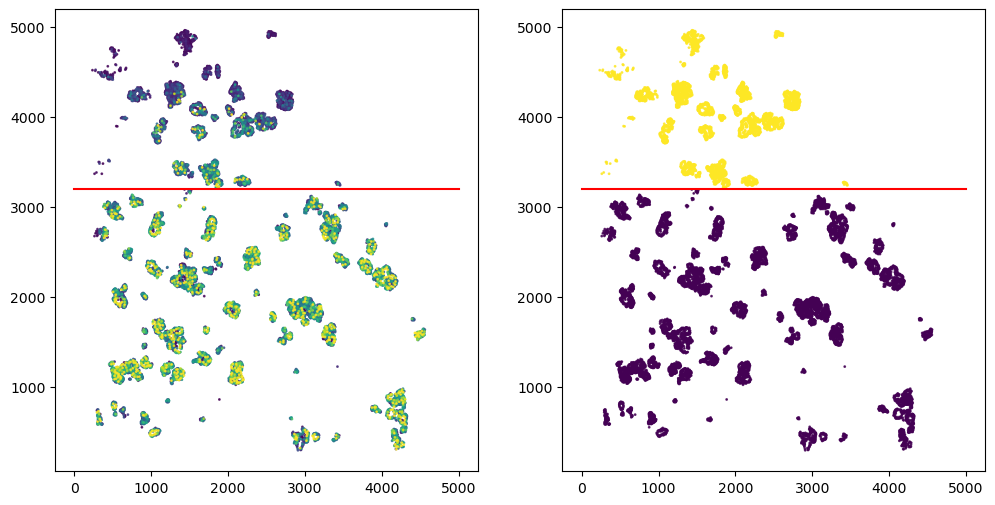

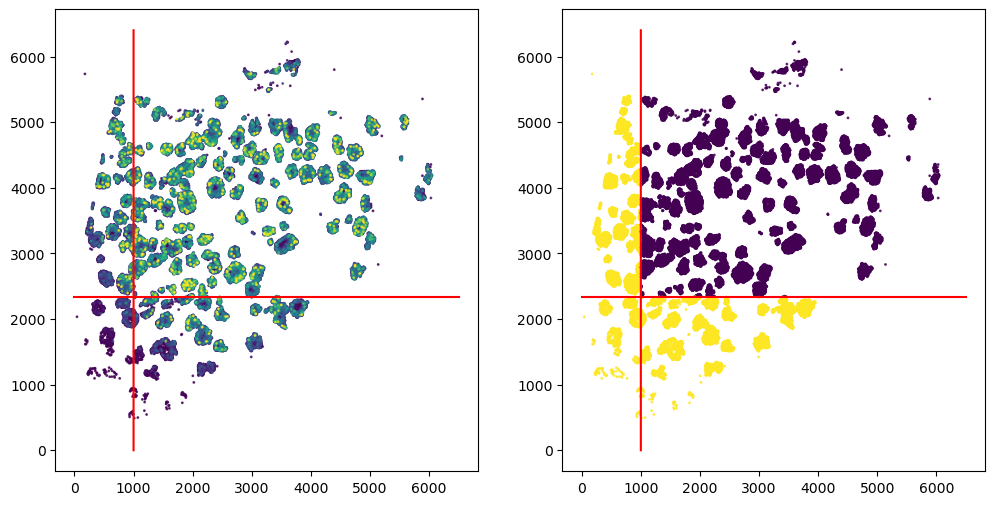

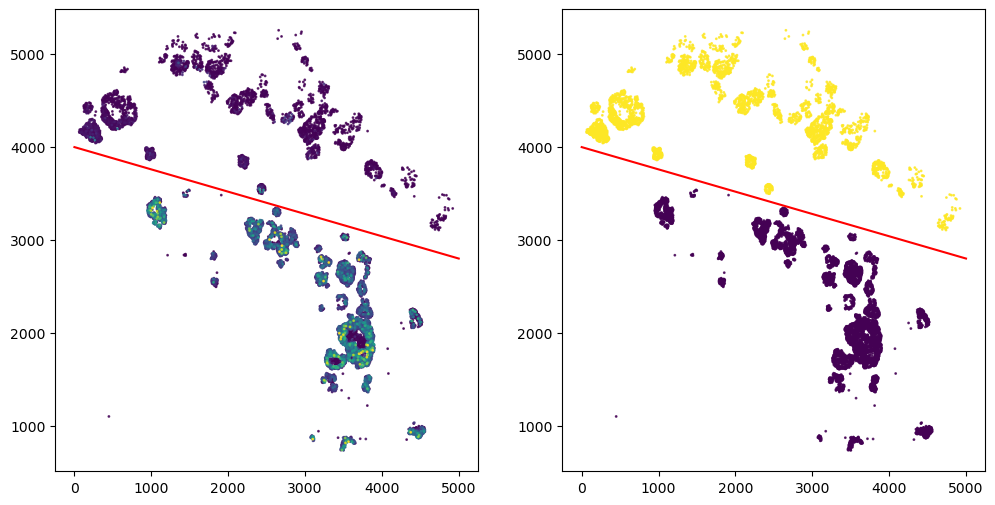

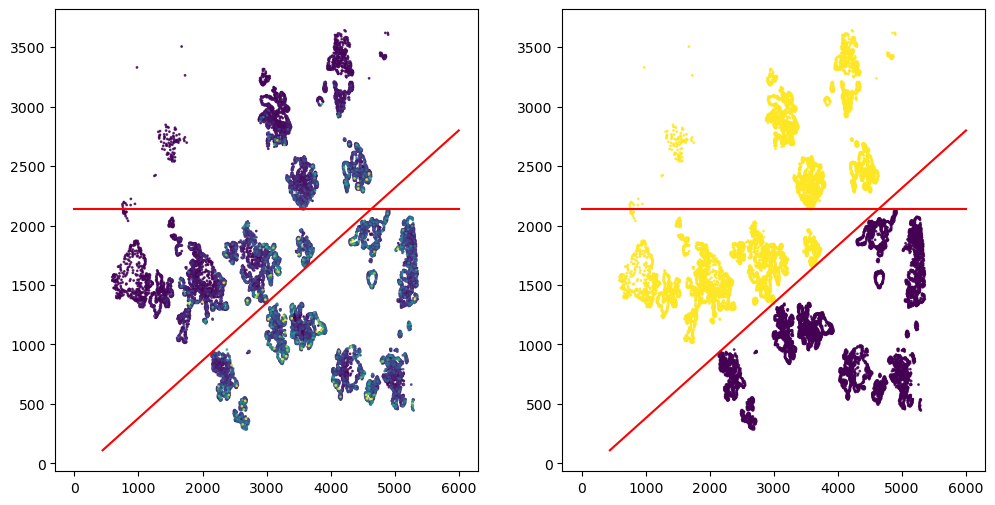

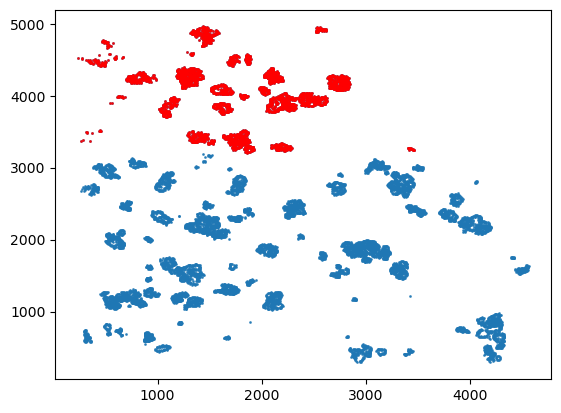

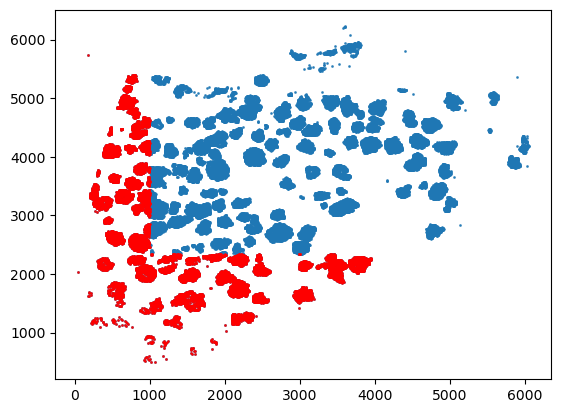

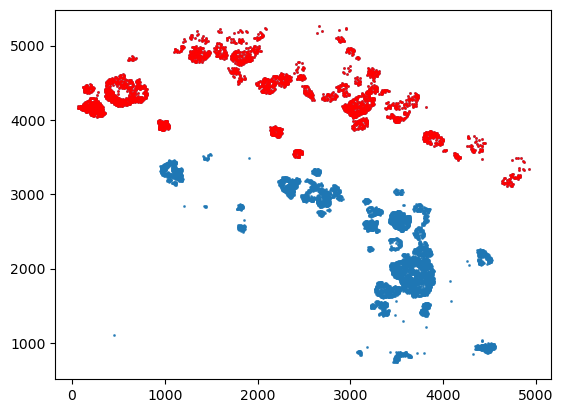

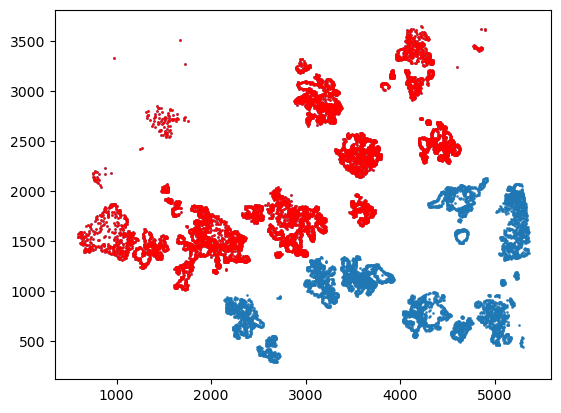

In [66]:
# Create DataFrame
df_coords_qc = pd.DataFrame(
    [
    {"sample": "1CFW", "xmin": 0, "xmax": 5000, "ymin": 3200, "ymax": 3200, "sign": 1},
    {"sample": "OAFN", "xmin": 0, "xmax": 6500, "ymin": 2340, "ymax": 2340, "sign": -1},
    {"sample": "OAFN", "xmin": 1000, "xmax": 1000.1, "ymin": 0, "ymax": 6400, "sign": 1},
    {"sample": "OWMY", "xmin": 0, "xmax": 5000, "ymin": 4000, "ymax": 2800, "sign": 1},
    {"sample": "03FO", "xmin": 440, "xmax": 6000, "ymin": 110, "ymax": 2800, "sign": 1},
    {"sample": "03FO", "xmin": 0, "xmax": 6000, "ymin": 2140, "ymax": 2140, "sign": 1},
])


dict_cell_id_qc = {}
for sample_name in df_coords_qc["sample"].unique():

    adata_sample = adata[(adata.obs["condition"] == "CRC_PDO") & (adata.obs["donor_corrected"] == sample_name)].copy()
    idx = np.argsort(adata_sample.obs['total_counts'])
    coords = adata_sample.obsm['spatial']

    # define line
    df_coords_qc_sample = df_coords_qc.query("sample == @sample_name")
    mask = np.zeros(coords.shape[0], dtype=bool)
    f, axs = plt.subplots(1, 2, figsize=(12, 6))

    for i,r in df_coords_qc_sample.iterrows():

        x_line = r[['xmin','xmax']].values
        y_line = r[['ymin','ymax']].values
        sign = r['sign']

        m = (y_line[1] - y_line[0]) / (x_line[1] - x_line[0])
        side = ((coords[:,1] - y_line[0]) - m * (coords[:,0] - x_line[0])) * sign
        mask |= (side >= 0) 

        axs[0].plot(x_line, y_line, color="red")
        axs[1].plot(x_line, y_line, color="red")

    axs[0].scatter(*coords[idx].T,c=adata_sample[idx].obs['total_counts'],alpha=.8,s=1,vmax=3000)
    axs[1].scatter(*coords.T,c=mask,alpha=.8,s=1)
    plt.show()
    
    k = tuple(adata_sample.obs[xenium_levels].iloc[0])
    dict_cell_id_qc[k] = adata_sample.obs_names[mask].tolist()

for sample_name in df_coords_qc["sample"].unique():

    adata_sample = adata[(adata.obs["condition"] == "CRC_PDO") & (adata.obs["donor_corrected"] == sample_name)].copy()
    idx = np.argsort(adata_sample.obs['total_counts'])
    coords = adata_sample.obsm['spatial']

    k = tuple(adata_sample.obs[xenium_levels].iloc[0])

    coords_excluded = coords[adata_sample.obs_names.isin(dict_cell_id_qc[k])]
    plt.scatter(*coords.T,alpha=.8,s=1)
    plt.scatter(*coords_excluded.T,c="red",alpha=.8,s=1)
    plt.show()

## write

In [67]:
df_cell_id = pd.DataFrame(
    [(key, val) for key, lst in dict_cell_id_qc.items() for val in lst],
    columns=["sample","cell_id"]
)
explode_xenium_levels = pd.DataFrame(df_cell_id["sample"].tolist(), columns=xenium_levels)
df_cell_id = pd.concat([explode_xenium_levels, df_cell_id[["cell_id"]],], axis=1)
df_cell_id['full_id'] = df_cell_id.agg("_".join, axis=1)
df_cell_id.to_csv(cfg['xenium_metadata_dir']+f"xenium_CRC_PDO_{segmentation}_cells_QC.csv")